# Clase 04 - Analisis de Datos

---

## Librerias

---

Las librerias a utilizar seran:

In [5]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import re

The only new libraries are:

- yfinance: According to its [documentation](https://ranaroussi.github.io/yfinance/reference/index.html): "The yfinance package provides easy access to Yahoo! Finance’s API to retrieve market data. It includes classes and functions for downloading historical market data, accessing ticker information, managing cache, and more."
- matplotlib: Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. We use two modules within the matplotlib library: (1) The [.pyplot](https://matplotlib.org/stable/api/pyplot_summary.html) module, which introduces plotting capabilities; and (2) the [.dates](https://matplotlib.org/stable/api/dates_api.html) module, which provides sophisticated date plotting capabilities, standing on the shoulders of python datetime.

## Funciones

---

#### Funcion sanitize_col

We define a function to clean/sanitize the column index of our dataframe. This function does the following:

1. It makes the name of the columns all uppercase and replaces whitespaces with underscores.
2. Erases any non uppercase letter or symbol different to an underscore.
3. Subsitutes the first ocurrance of 1 or more contiguous "_" with just one underscore, and removes leading and trailing underscores.

We will loop through this function wich each value in the columns index later on.


In [6]:
def sanitize_col(name: str) -> str:    # By using the "-> str" we specify that output of this function must be an object of type string
    name = name.upper().replace(" ", "_")    # This makes name all uppercase and replaces whitespaces with "_"
    name = re.sub(r"[^A-Z_]", "", name)    # This regex pattern will match any single character that is a lowercase letter, a digit, a space, a symbol (like !, @, #, etc.),
                                           # or any other non-uppercase-letter, non-underscore character. It will replace matches on the string "name"
    name = re.sub(r"_+", "_", name).strip("_")    # Substitute the first ocurrance of 1 or more "_" with just one "_" and remove leading and trailing underscores
    return name

## Using yfinance to dowload stock data

---

Now, we use the yfinance library to download the historic data of the price of the following stocks: 

- "AAPL"
- "MSFT"
- "AMZN"
- "GOOGL"
- "META"
- "NVDA"
- "TSLA"
- "JPM"
- "JNJ"
- "XOM"

We'll use the yfinance function [`yf.download`](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download) to download yahoo tickers data. This function has several parameters, the most important ones being:

- tickers: str or list of tickers to download
- start: download start date string (YYYY-MM-DD)
- end: download end date string (YYYY-MM-DD)
- auto_adjust: Adjust all OHLC (Open, High, Low, and Close) automatically? The default is True. - THIS PARAMETER HIDES IMPORTANT INSIGHTS.

In [7]:
tks = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "JNJ", "XOM"]

inicio = "2021-01-01"
final = "2025-12-31"

data = yf.download(tickers=tks, start=inicio, end=final, auto_adjust=False, progress=True, threads=True)

[*********************100%***********************]  10 of 10 completed


### Understanging how adjusted close prices work

When a company pays dividens to stock holders or performs a stock split (incresing the number of shares while reducing stock price), the price of the stock naturally adjusts in the market (pues pagar dividendos aumenta el capital y disminuye los activos de la empresa). But for the historical analysis of the price of the stock, we need said prices to be all adjusted across the time series for the data to be comparable. 

The data provider (Yahoo finance) internally adjusts all prices (Open, High, Low and Close) for Corporate Stock Actions like divends, splits and reverse splits. When downloading the historic data of a ticker using .download, we need then to specify if we want yfinance to automatically adjust all prices (Open, High, Low and Close) instead of returning a separate column of adjusted prices. 

By default, it used to be that it would not automatically adjust prices and give an extra column with the adjusted data. But now by default it does. So, to still keep the unadjusted prices we include `auto_adjust=False`.

## EDA

---

In [8]:
display(data)

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-01-04  125.856705  159.331497   85.599030  135.059647  110.051926   
2021-01-05  127.412712  160.925507   86.289322  136.647568  110.650734   
2021-01-06  123.123840  156.919006   85.437851  137.933456  115.846443   
2021-01-07  127.325211  158.108002   87.989761  138.399445  119.650719   
2021-01-08  128.424225  159.134995   89.154640  138.114655  119.782852   
...                ...         ...         ...         ...         ...   
2025-12-23  272.105377  232.139999  314.128876  204.691833  324.466400   
2025-12-24  273.554016  232.380005  313.869049  206.681259  327.691864   
2025-12-26  273.144409  232.520004  313.289459  206.532059  326.437531   
2025-12-29  273.504089  232.070007  313.339417  206.462418  322.296204   
2025-12-30  272.824707  232.529999  313.629242  205.815857  321.967712   

Price                                                                   ...  \
Ticker            META        MSFT        NVDA        TSLA         XOM  ...   
Date                                                                    ...   
2021-01-04  266.845947  208.406540   13.076016  243.256668   33.693790  ...   
2021-01-05  268.860107  208.607574   13.366435  245.036667   35.317577  ...   
2021-01-06  261.259796  203.198547   12.578443  251.993332   36.218800  ...   
2021-01-07  266.647461  208.980942   13.305861  272.013336   36.502949  ...   
2021-01-08  265.486603  210.254257   13.238801  293.339996   36.908913  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-23  664.371155  485.741333  189.199768  485.559998  118.629288  ...   
2025-12-24  666.978943  486.908630  188.599792  485.399994  118.430618  ...   
2025-12-26  662.722595  486.599365  190.519684  475.190002  118.321342  ...   
2025-12-29  658.126526  485.990753  188.209808  459.640015  119.731941  ...   
2025-12-30  665.380310  486.369904  187.529846  454.429993  120.188896  ...   

Price          Volume                                                    \
Ticker           AAPL      AMZN     GOOGL       JNJ       JPM      META   
Date                                                                      
2021-01-04  143301900  88228000  37324000  11765900  16819900  15106100   
2021-01-05   97664900  53110000  20360000   9602300  13731200   9871600   
2021-01-06  155088000  87896000  46588000   8230100  24909100  24354100   
2021-01-07  109578200  70290000  41936000   7747200  21940400  15789800   
2021-01-08  105158200  70754000  35484000   8228900  12035100  18528300   
...               ...       ...       ...       ...       ...       ...   
2025-12-23   29642000  29230200  25478700   7047300   6668300   8486800   
2025-12-24   17910600  11420500  10097400   2376500   4289300   5627500   
2025-12-26   21521800  15994700  10899000   2316700   4158300   7133800   
2025-12-29   23715200  19797900  19621800   4348900   8635300   8506500   
2025-12-30   22139600  21910500  17380900   3937400   7904300   9187500   

Price                                                 
Ticker          MSFT       NVDA       TSLA       XOM  
Date                                                  
2021-01-04  37130100  560640000  145914600  27764700  
2021-01-05  23823000  322760000   96735600  44035100  
2021-01-06  35930700  580424000  134100000  36484800  
2021-01-07  27694500  461480000  154496700  29528100  
2021-01-08  22956200  292528000  225166500  28628200  
...              ...        ...        ...       ...  
2025-12-23  14683600  174873600   58223600  12567600  
2025-12-24   5855900   65528500   41285400   6137400  
2025-12-26   8842200  139740300   58780700   8066100  
2025-12-29  10893400  120006100   66263000  14782500  
2025-12-30  13944500   97687300   59238500  11150500  

[1254 rows x 60 columns]

In [9]:
display(data.columns)

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            ('Adj Close',   'XOM'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (    'Close',   'XOM'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  'META'),
            (     'High',  'MSFT'),
            (     'High',  '

Observe we have a multi-column index.

In [10]:
display(data.columns.get_level_values(0))

Index(['Adj Close', 'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close',
       'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close',
       'Close', 'Close', 'Close', 'Close', 'Close', 'Close', 'Close', 'Close',
       'Close', 'Close', 'High', 'High', 'High', 'High', 'High', 'High',
       'High', 'High', 'High', 'High', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Open', 'Open', 'Open', 'Open',
       'Open', 'Open', 'Open', 'Open', 'Open', 'Open', 'Volume', 'Volume',
       'Volume', 'Volume', 'Volume', 'Volume', 'Volume', 'Volume', 'Volume',
       'Volume'],
      dtype='object', name='Price')

## Manipulacion de datos

---

In [11]:
# Separar df volumen y df precios

adj = data["Adj Close"].copy()
vol = data["Volume"].copy()

display(adj.head())
display(vol.head())

display(adj.columns)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,33.693790
2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,35.317577
2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,36.218800
2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,36.502949
2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,36.908913


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


Index(['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA',
       'XOM'],
      dtype='object', name='Ticker')

Now we "sanitize" the column names using the above defined function `sanitize_col`. We use dictionary comprehension.

In [12]:
adj_ren = adj.rename(columns= {t: f"ADJ_CLOSE_{sanitize_col(t)}" for t in adj.columns})
vol_ren = vol.rename(columns= {t: f"VOLUMEN_{sanitize_col(t)}" for t in adj.columns})

display(adj_ren.head())
display(vol_ren.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
Date,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,33.693790
2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,35.317577
2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,36.218800
2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,36.502949
2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,36.908913


Ticker,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


We now use a left join to merge both the adjusted prices dataframe and the volumes dataframe:

In [13]:
df_p_v = pd.merge(adj_ren, vol_ren, on = "Date", how= "left" )

display(df_p_v.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Date,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,33.693790,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,35.317577,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,36.218800,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,36.502949,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,36.908913,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


### An interesting property of dataframes

In the previous dataframe (the above printed one) we can see that the top left-most cell has the string "Ticker". At first we may think that it is the name of the index of the dataframe. Since it does not add meaningfull information it would be ideal to change it to "", and for that we would do:

In [14]:
df = df_p_v.copy().reset_index()
df.index.name = ""
display(df)
display(df.columns.name)

Ticker,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


'Ticker'

Observe how this did not change the name of the index. The issue here lies on the fact that any DataFrame is defined as a tabular arrangement of data, along with a row index and a column index (both index type objects). The string "Ticker" is not the name of the index, but the name of the column index. 

To showcase this, we can change the name of the index to "Ticker_temp" and see what happens:

In [15]:
df.index.name = "Ticker_2"
display(df)
display(df.index.name)
display(df.columns.name)

Ticker,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Ticker_2,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


'Ticker_2'

'Ticker'

Now we have a header for the row index and the column index of the dataframe `df`. We now change both to "".

In [16]:
df = df_p_v.copy().reset_index()

df.columns.name = ""
df.index.name = ""

display(df)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


## EDA_2

---

In [17]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1254 non-null   datetime64[ns]
 1   ADJ_CLOSE_AAPL   1254 non-null   float64       
 2   ADJ_CLOSE_AMZN   1254 non-null   float64       
 3   ADJ_CLOSE_GOOGL  1254 non-null   float64       
 4   ADJ_CLOSE_JNJ    1254 non-null   float64       
 5   ADJ_CLOSE_JPM    1254 non-null   float64       
 6   ADJ_CLOSE_META   1254 non-null   float64       
 7   ADJ_CLOSE_MSFT   1254 non-null   float64       
 8   ADJ_CLOSE_NVDA   1254 non-null   float64       
 9   ADJ_CLOSE_TSLA   1254 non-null   float64       
 10  ADJ_CLOSE_XOM    1254 non-null   float64       
 11  VOLUMEN_AAPL     1254 non-null   int64         
 12  VOLUMEN_AMZN     1254 non-null   int64         
 13  VOLUMEN_GOOGL    1254 non-null   int64         
 14  VOLUMEN_JNJ      1254 non-null   int64  

None

In [18]:
display(df.describe())

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
count,1254,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,...,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03
mean,2023-07-01 14:52:14.928229888,179.299863,163.349711,145.411313,152.220556,172.997314,385.883647,341.831311,67.095499,265.416786,...,6.984941e+07,5.765009e+07,3.234882e+07,8.318995e+06,1.114788e+07,2.177274e+07,2.554321e+07,3.950968e+08,9.979395e+07,1.984098e+07
min,2021-01-04 00:00:00,113.334129,81.820000,82.746109,132.923325,94.269775,88.217728,203.198547,11.212296,108.099998,...,1.791060e+07,1.142050e+07,9.701400e+06,2.316700e+06,3.220500e+06,4.726100e+06,5.855900e+06,6.552850e+07,2.940180e+07,6.137400e+06
25%,2022-03-31 06:00:00,145.947067,131.932499,113.952311,144.374199,130.024208,235.199287,264.165627,19.377610,210.677502,...,4.839515e+07,3.992260e+07,2.344232e+07,5.809450e+06,7.905950e+06,1.289022e+07,1.891820e+07,2.436113e+08,7.156680e+07,1.418028e+07
50%,2023-07-01 12:00:00,171.515816,165.522751,136.438080,149.559662,143.814964,331.607712,323.169495,41.796545,248.845001,...,6.313855e+07,5.153015e+07,2.904940e+07,7.019900e+06,9.671350e+06,1.784310e+07,2.319270e+07,3.805520e+08,9.311910e+07,1.766255e+07
75%,2024-09-29 06:00:00,210.447926,187.189999,165.436874,156.037788,210.118355,531.967346,413.133728,118.471853,308.912498,...,8.455132e+07,6.755260e+07,3.686685e+07,8.672425e+06,1.292250e+07,2.549598e+07,2.949325e+07,5.064938e+08,1.190400e+08,2.286698e+07
max,2025-12-30 00:00:00,285.922455,254.000000,323.001190,213.037460,327.691864,788.148987,539.825195,207.017273,489.880005,...,3.186799e+08,2.726620e+08,1.274901e+08,1.513195e+08,5.441880e+07,2.323166e+08,9.042890e+07,1.543911e+09,3.065906e+08,8.443940e+07
std,NaN,39.986084,40.317243,45.514736,12.933523,61.113632,186.467779,89.125851,57.396393,77.017217,...,2.995081e+07,2.718046e+07,1.379020e+07,7.804490e+06,5.225449e+06,1.583683e+07,1.009796e+07,1.834432e+08,3.915409e+07,8.391090e+06


## Visualizations

---

We now explore matplotlib capabilities for developing plots of all kinds.

The following two links have more information about common plots in python:

- https://python-graph-gallery.com/
- https://matplotlib.org/stable/gallery/index.html

### The Basics of Matplotlib




### Histograms

According to [Python-graph-library](https://python-graph-gallery.com/histogram/): "A Histogram represents the distribution of a numeric variable for one or several groups. The values are split in bins, each bin is represented as a bar."

#### How many bins?

Let n be the sample size. The two most simple techniques for determining the amount of bins to include in the histogram are:

- The square root rule: The number k of bins is given by k=sqrt(n), rounded up.
- Sturges' rule: Best for small, normally distributed datasets (n<30). The number k of bins is given by k=log_2(n)-1

#### How can we create the histogram?

We now create the histogram:

np.int64(1254)

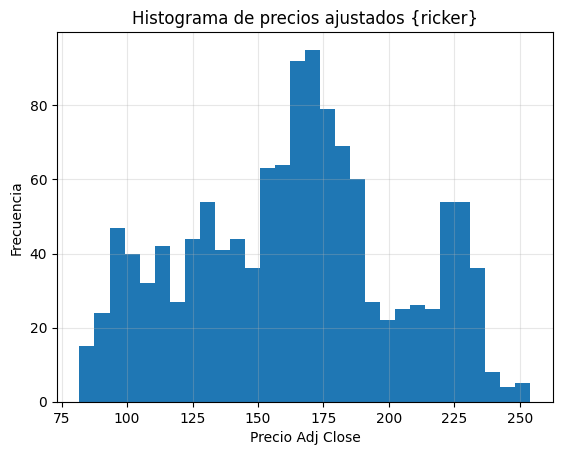

In [19]:
ticker = "AMZN"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"

s = prices[col].dropna()

display(s.count())

plt.figure()
plt.hist(s.values, bins=bins)
plt.title("Histograma de precios ajustados {ricker}")
plt.ylabel("Frecuencia")
plt.xlabel("Precio Adj Close")
plt.grid(True, alpha=0.3)
plt.show()

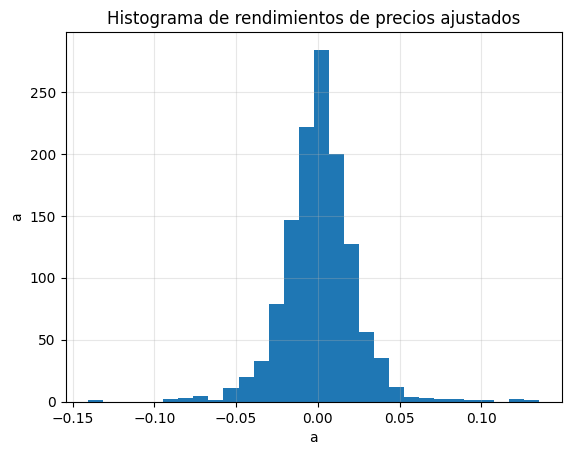

In [20]:
# Hacer histograma de rendimientos

# Reparto de utilidades. Puede o no existir un reparto de dividendos.

prices_2 = df.copy()

s = prices_2[col].dropna()
rendimientos = [(s[x]-s[x-1])/s[x-1] if x > 0 else 0 for x in range(0,s.count())]
# rendimientos = s[1:].values/s[:,-1].values - 1

# s[1:]/s[:,-1] - 1

# rendimientos = s.pct_change()     # Funcion que hace lo anterior

plt.figure()
plt.hist(rendimientos, bins=bins, )
plt.title("Histograma de rendimientos de precios ajustados")
plt.ylabel("a")
plt.xlabel("a")
plt.grid(True, alpha=0.3)
plt.show()


### Heatmap

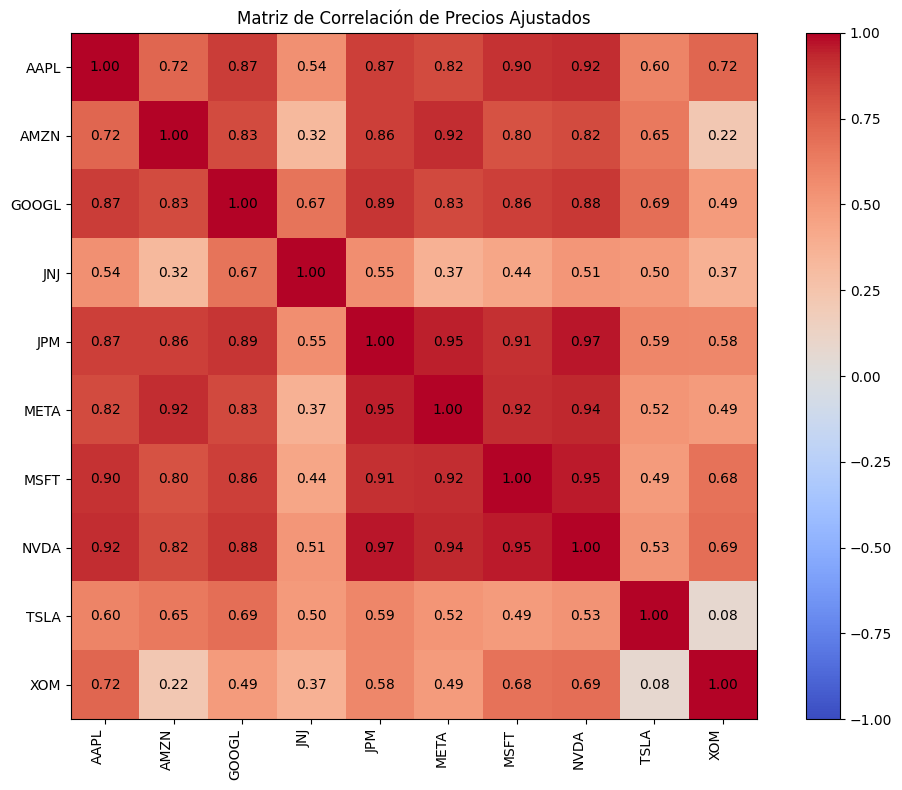

In [21]:
prices_2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ_CLOSE")]
prices_2 = prices_2[price_cols]

corr = prices_2.corr(method = "pearson")    # Matrix de correlaciones

labels = [c.replace("ADJ_CLOSE_", "") for c in corr.columns]    # Remueve todo menos el ticker
fig, ax = plt.subplots(figsize = (10,8))    # Create a figure containing a single Axes.
im = ax.imshow(corr.values, cmap = "coolwarm", vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "black")

ax.set_title("Matriz de Correlación de Precios Ajustados")
fig.tight_layout()
plt.colorbar(im, ax = ax)
plt.show()

In [22]:
display(corr)

,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
,,,,,,,,,,
ADJ_CLOSE_AAPL,1.000000,0.720197,0.872370,0.541149,0.865433,0.821542,0.900263,0.917982,0.596082,0.723974
ADJ_CLOSE_AMZN,0.720197,1.000000,0.826757,0.322267,0.862170,0.918622,0.801995,0.821215,0.647739,0.222131
ADJ_CLOSE_GOOGL,0.872370,0.826757,1.000000,0.671703,0.893941,0.832668,0.861192,0.883092,0.690981,0.488652
ADJ_CLOSE_JNJ,0.541149,0.322267,0.671703,1.000000,0.549742,0.371474,0.435155,0.514480,0.499087,0.367434
ADJ_CLOSE_JPM,0.865433,0.862170,0.893941,0.549742,1.000000,0.951334,0.912539,0.966349,0.588539,0.579129
ADJ_CLOSE_META,0.821542,0.918622,0.832668,0.371474,0.951334,1.000000,0.920448,0.935256,0.518375,0.486916
ADJ_CLOSE_MSFT,0.900263,0.801995,0.861192,0.435155,0.912539,0.920448,1.000000,0.953806,0.489687,0.676819
ADJ_CLOSE_NVDA,0.917982,0.821215,0.883092,0.514480,0.966349,0.935256,0.953806,1.000000,0.527563,0.689505
ADJ_CLOSE_TSLA,0.596082,0.647739,0.690981,0.499087,0.588539,0.518375,0.489687,0.527563,1.000000,0.077925


#### Tarea Obtener el heatmap de correlación de rendimientos

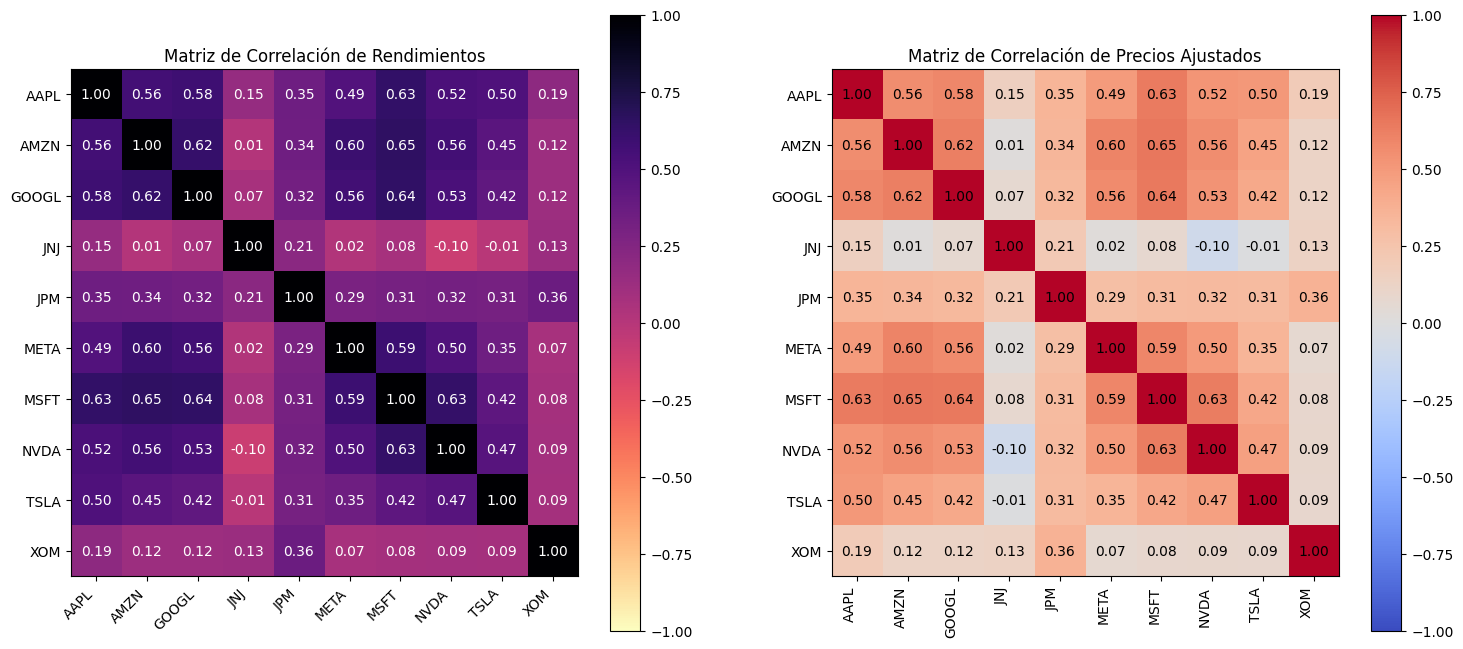

In [23]:
prices_2_v2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ_CLOSE")]
prices_2_v2 = prices_2_v2[price_cols].dropna()
prices_2_v2 = prices_2_v2.pct_change()

corr = prices_2_v2.corr(method = "pearson")
labels = [c.replace("ADJ_CLOSE_", "") for c in corr.columns]
fig, (ax, ax2) = plt.subplots(1, 2, figsize = (18,8))    # Create a figure containing a single Axes.

im = ax.imshow(corr.values, cmap = "magma_r", vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 45, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "w")

ax.set_title("Matriz de Correlación de Rendimientos")
#fig.tight_layout()
plt.colorbar(im, ax = ax)

im = ax2.imshow(corr.values, cmap = "coolwarm", vmin = -1, vmax = 1)

ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation = 90, ha = "right")
ax2.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax2.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "black")

ax2.set_title("Matriz de Correlación de Precios Ajustados")
#fig.tight_layout()
plt.colorbar(im, ax = ax2)



plt.show()

### Boxplot

C:\Users\ossia\AppData\Local\Temp\ipykernel_18136\1381224098.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(s.values, labels = [ticker], showfliers = True)


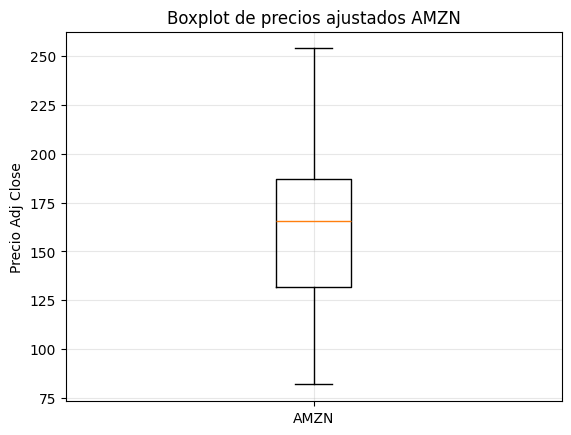

In [24]:
ticker = "AMZN"
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
if col not in prices.columns:
    disponibles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")])
    raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponibles}")

s = prices[col].dropna()

plt.figure()
plt.boxplot(s.values, labels = [ticker], showfliers = True)
plt.title(f"Boxplot de precios ajustados {ticker}")
plt.ylabel("Precio Adj Close")
plt.grid(True, alpha = 0.3)
plt.show()

# IQR = Percentil75 - Percentil25
# todo lo que esté por debajo de [Percentil25 - 1.5*IQR] o por encima de [Percentil75 + 1.5*IQR] se considera outlier

# skew
# kurtosis


#### Tarea Obtener boxplot de rendimientos

C:\Users\ossia\AppData\Local\Temp\ipykernel_18136\3880393385.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(s.values, labels = [ticker], showfliers = True)


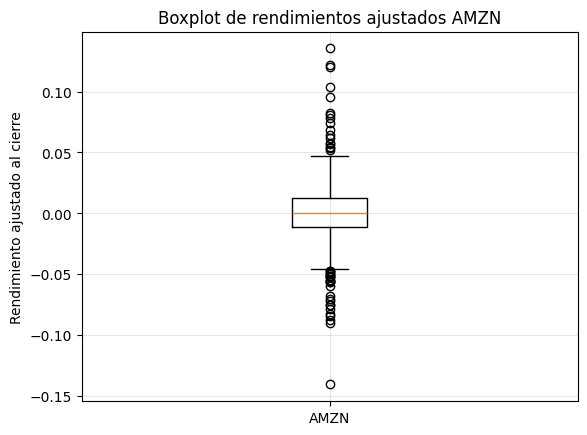


1       0.010004
2      -0.024897
3       0.007577
4       0.006496
5      -0.021519
          ...   
1249    0.016241
1250    0.001034
1251    0.000602
1252   -0.001935
1253    0.001982
Name: ADJ_CLOSE_AMZN, Length: 1253, dtype: float64

In [25]:
ticker = "AMZN"

col = f"ADJ_CLOSE_{ticker}"
if col not in prices_2_v2.columns:
    disponibles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")])
    raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponibles}")

s = prices_2_v2[col].dropna()

plt.figure()
plt.boxplot(s.values, labels = [ticker], showfliers = True)
plt.title(f"Boxplot de rendimientos ajustados {ticker}")
plt.ylabel("Rendimiento ajustado al cierre")
plt.grid(True, alpha = 0.3)
plt.show()

display(s)

### Serie de Tiempo

C:\Users\ossia\AppData\Local\Temp\ipykernel_18136\3580577236.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y[col] = (s - s.min())/(s.max() - s.min())


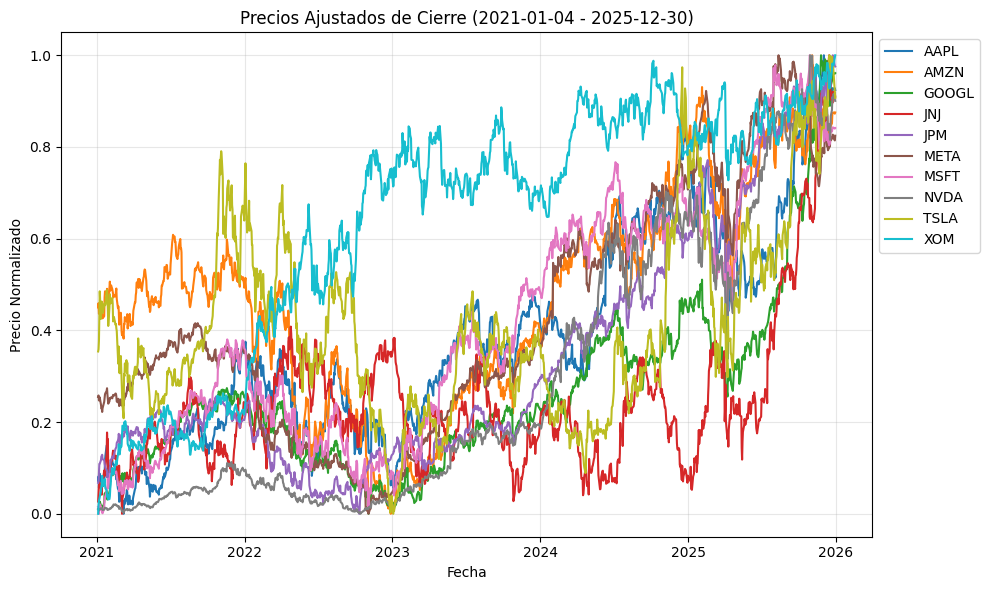

,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
DATE,,,,,,,,,,
2021-01-04,0.072557,0.450177,0.011875,0.026666,0.067612,0.255208,0.015471,0.009518,0.354017,0.000000
2021-01-05,0.081573,0.459435,0.014748,0.046487,0.070177,0.258086,0.016068,0.011001,0.358680,0.018773
2021-01-06,0.056723,0.436166,0.011204,0.062537,0.092436,0.247227,0.000000,0.006977,0.376901,0.029193
2021-01-07,0.081066,0.443071,0.021825,0.068354,0.108734,0.254925,0.017177,0.010692,0.429340,0.032478
2021-01-08,0.087434,0.449036,0.026674,0.064799,0.109300,0.253266,0.020960,0.010350,0.485201,0.037171
...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.919942,0.873040,0.963071,0.895828,0.986182,0.823157,0.839336,0.909004,0.988685,0.981969
2025-12-24,0.928336,0.874434,0.961990,0.920661,1.000000,0.826883,0.842803,0.905940,0.988265,0.979672
2025-12-26,0.925962,0.875247,0.959577,0.918798,0.994626,0.820802,0.841885,0.915745,0.961522,0.978409


In [26]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

display(Y)

### Tarea: Evolución del valor de las acciones respecto al año anterior y hace dos años

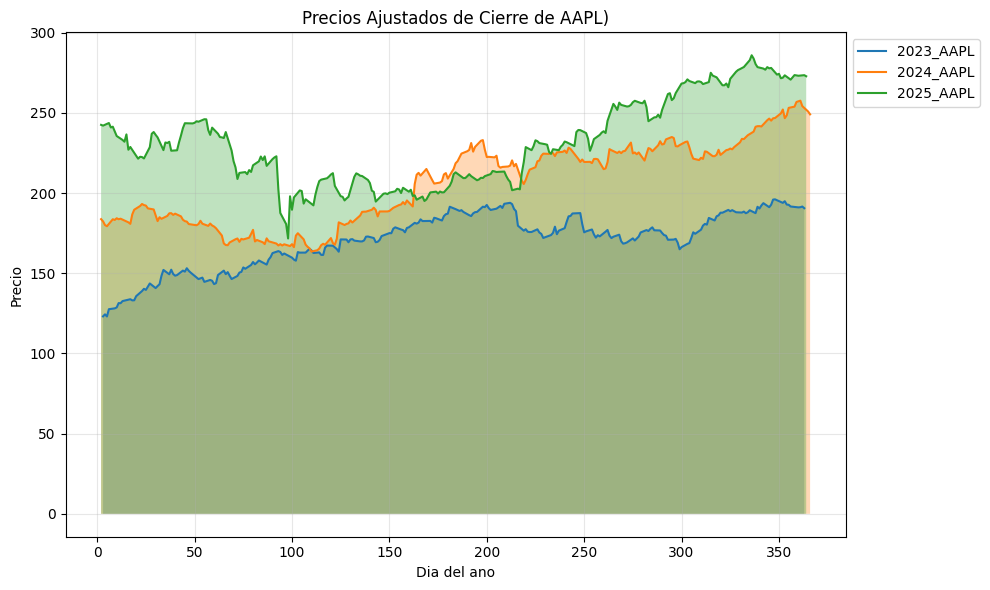

Index([  3,   4,   5,   6,   9,  10,  11,  12,  13,  17,
       ...
       349, 352, 353, 354, 355, 356, 360, 361, 362, 363],
      dtype='int32', name='DATE', length=250)

In [27]:
t_dfx = df.copy()
t_dfx = t_dfx.loc[:, ["Date"]+([column for column in t_dfx.columns if "ADJ_CLOSE" in column])]
t_dfx["DATE"] = pd.to_datetime(t_dfx["Date"], errors="coerce")    # Forzamos el cambio del tipo de dato a datetime para la columna con nombre "Date", y con la asignacion, cambiamos el
                                                                  # nombre de la columna a "DATE"
t_dfx = t_dfx.drop(columns=["Date"])
t_dfx = t_dfx.set_index("DATE", drop=True)

ticker = "AAPL"

t_dfx = t_dfx.loc[:, [column for column in t_dfx.columns if ticker in column]]

#normalize = False

#s = t_dfx
#t_dfx = (s - s.min())/(s.max() - s.min())


Y_2023 = t_dfx.loc["2023-01-01":"2023-12-31"]
Y_2024 = t_dfx.loc["2024-01-01":"2024-12-31"]
Y_2025 = t_dfx.loc["2025-01-01":"2025-12-31"]

normalize = False

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(Y_2023.index.dayofyear, Y_2023["ADJ_CLOSE_" + ticker].values, label="2023_"+ticker)
ax.fill_between(Y_2023.index.dayofyear, Y_2023["ADJ_CLOSE_" + ticker].values, alpha = 0.3)
ax.plot(Y_2024.index.dayofyear, Y_2024["ADJ_CLOSE_" + ticker].values, label="2024_"+ticker)
ax.fill_between(Y_2024.index.dayofyear, Y_2024["ADJ_CLOSE_" + ticker].values, alpha = 0.3)
ax.plot(Y_2025.index.dayofyear, Y_2025["ADJ_CLOSE_" + ticker].values, label="2025_"+ticker)
ax.fill_between(Y_2025.index.dayofyear, Y_2025["ADJ_CLOSE_" + ticker].values, alpha = 0.3)

#locator = mdates.AutoDateLocator()
#formatter = mdates.ConciseDateFormatter(locator)
#ax.xaxis.set_major_locator(locator)
#ax.xaxis.set_major_formatter(formatter)



ax.set_title(f"Precios Ajustados de Cierre de {ticker})")
ax.set_xlabel("Dia del ano")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()


#display(t_dfx)
display(Y_2023.index.dayofyear)

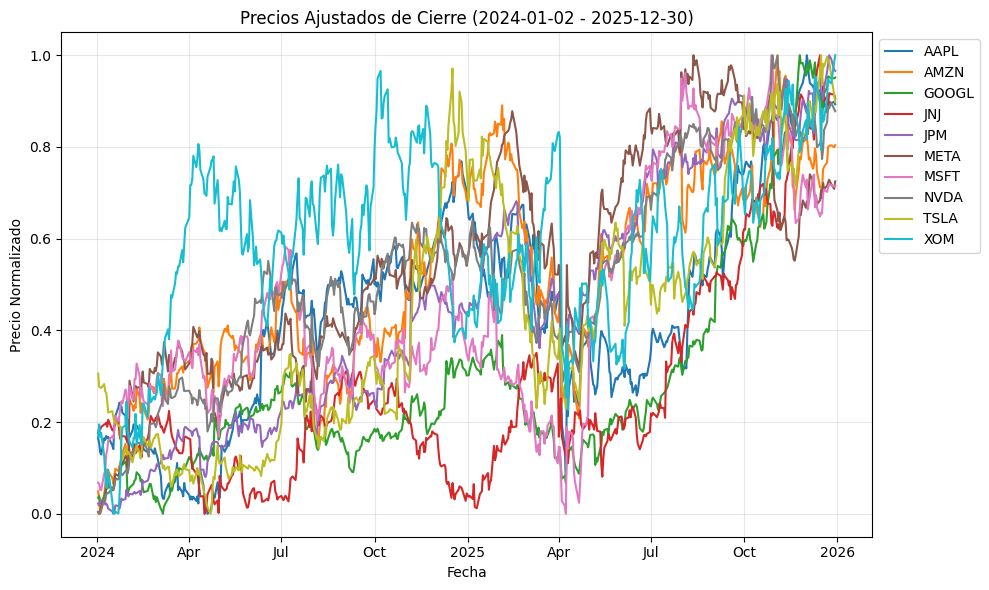

In [28]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
Y = Y.loc["2024-01-02":"2025-12-30"]    # Solo cambiamos el ano para ajustar la temporalidad


if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [29]:
Y.index

years = re.compile(r"2024|2025")

new_dates = [x for x in Y.index if re.search(years, str(x))]
pd.to_datetime(new_dates, errors="coerce")

DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-16',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', length=501, freq=None)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
,,,,,,,,,,,,,,,,,,,,,
753,2024-01-02,183.731308,149.929993,137.037369,149.659744,163.843582,343.593628,364.589478,48.138569,248.419998,...,82488700,47339400,23711200,9622100,9977400,19042200,25258600,411254000,104654200,23483000
754,2024-01-03,182.355576,148.470001,137.781265,150.595306,163.129486,341.787781,364.324036,47.539936,238.449997,...,58414500,49425500,24212100,8232000,9852300,15451100,23083500,320896000,121082600,23490800
755,2024-01-04,180.039658,144.570007,135.271988,150.277237,164.212021,344.417175,361.709106,47.968681,237.929993,...,71983600,56039800,27137700,6766600,11972500,12099900,20901500,306535000,102629300,19395200
756,2024-01-05,179.317184,145.240005,134.617401,150.745010,165.035904,349.209625,361.522278,49.067009,237.490005,...,62379700,45153100,22513900,5602500,10066000,13920700,21004600,415039000,92488900,15827400
757,2024-01-08,183.652130,149.100006,137.701889,151.119232,164.796417,355.867310,368.344757,52.221081,240.449997,...,59144500,46757100,21404000,6569800,11229900,13890200,23134000,642510000,85166600,23370100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


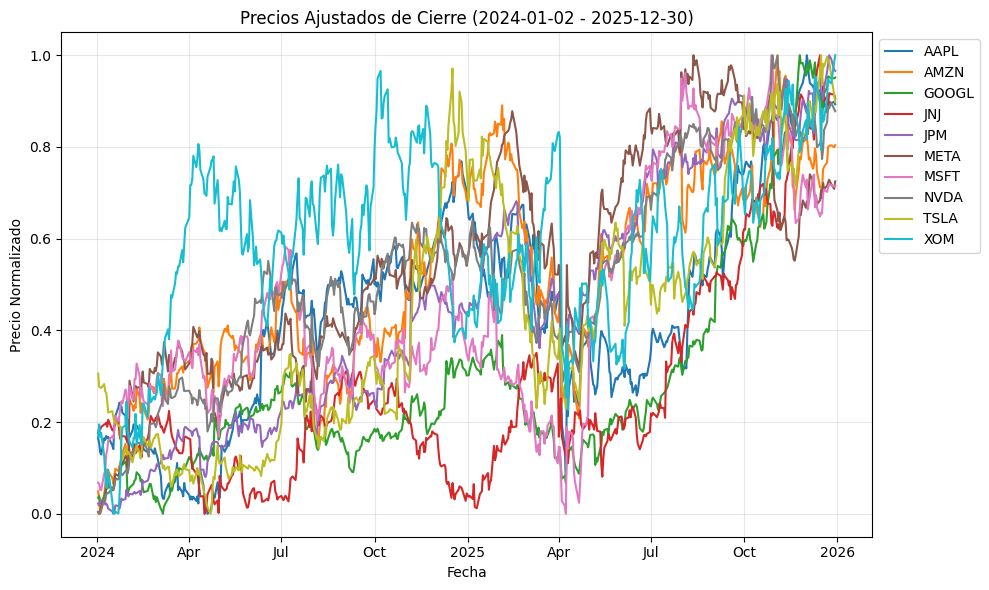

In [30]:
Y.index

years = re.compile(r"2024|2025")

YY = [x for x in Y.index if re.search(years, str(x))]
YY = pd.to_datetime(YY, errors="coerce")

dfx_v2 = df.copy()
#dfx_v2 = dfx_v2.loc["2024-01-02":"2025-12-30"]
dfx_v2 = dfx_v2.loc[dfx_v2["Date"].isin(YY)]

display(dfx_v2)

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

### Time Series Con Área Bajo la Curva

C:\Users\ossia\AppData\Local\Temp\ipykernel_18136\102694096.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y[col] = (s - s.min())/(s.max() - s.min())


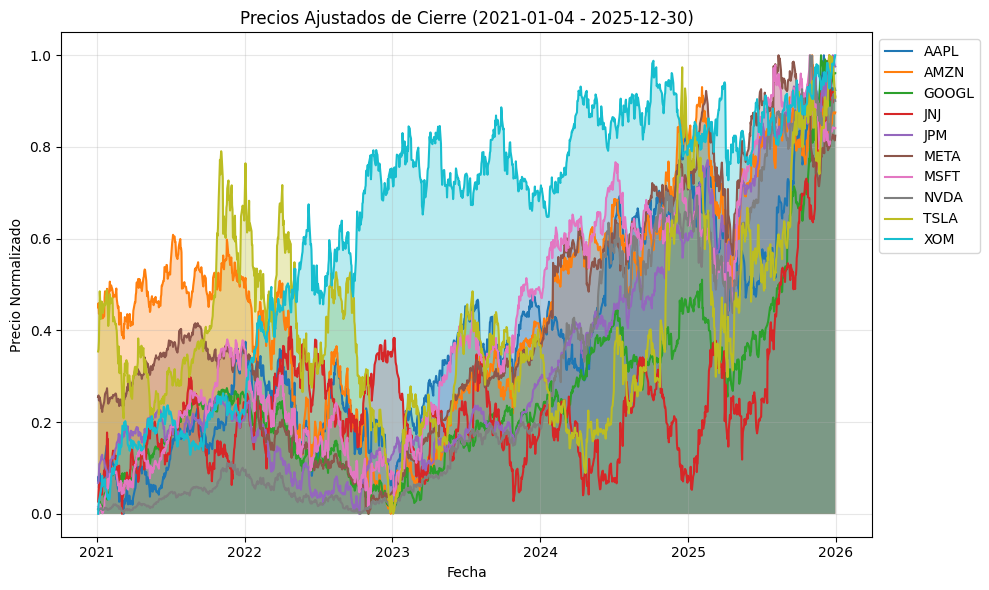

In [31]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))
        ax.fill_between(series.index, series.values, alpha = 0.3)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [32]:
# Tarea Evolución del valor de lals acciones respecto al año anterior y hace dos años con área bajo la curva

### Pie Chart

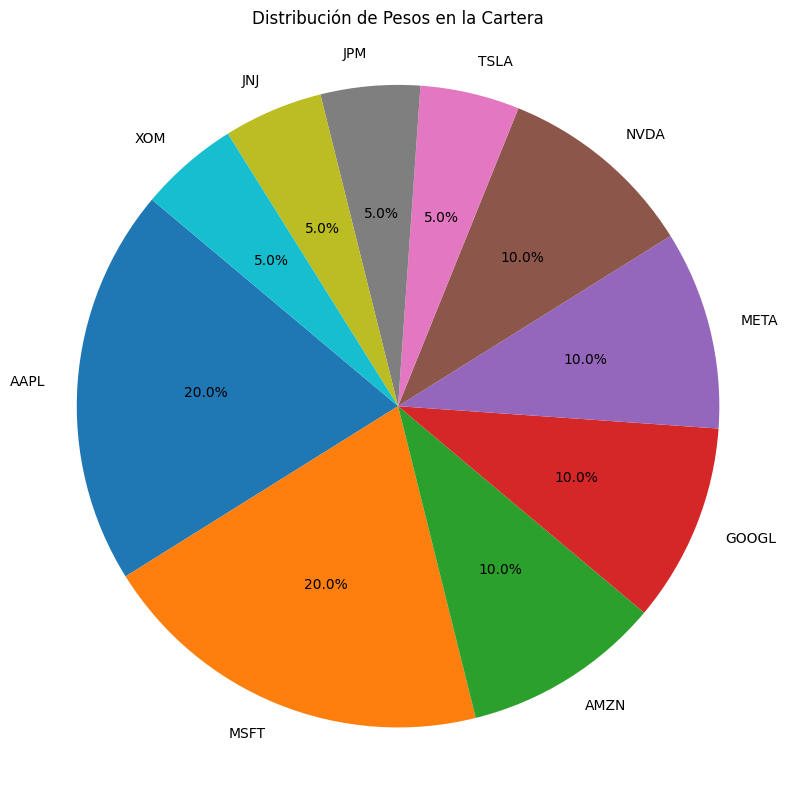

In [33]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

labels = list(weights.keys())
values = list(weights.values())

plt.figure(figsize = (8,8))
wedges, texts, autotexts = plt.pie(values, labels = labels, autopct = "%1.1f%%", startangle = 140)
plt.title("Distribución de Pesos en la Cartera")
plt.axis("equal")
plt.tight_layout()
plt.show()


### Tarea: piechart con la proporción del rendimiento total aportada por acción

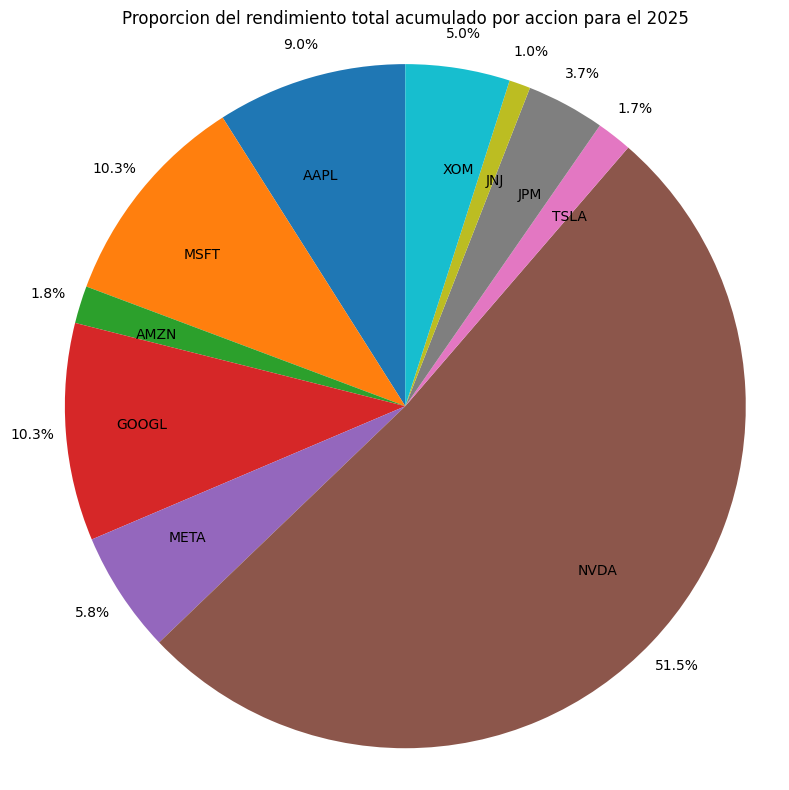

In [34]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

labels = list(weights.keys())
values = list(weights.values())

prices = df.copy()
prices["DATE"] = pd.to_datetime(prices["Date"], errors="coerce")
prices = prices.sort_values("DATE")

start_2021 = pd.Timestamp("2021-01-01")
end_2025   = pd.Timestamp("2025-12-31")

mask_2025 = (prices["DATE"] >= start_2021) & (prices["DATE"] <= end_2025)
p25 = prices.loc[mask_2025].reset_index(drop=True)

# Retornos por acción (YTD 2025) usando Adj Close
rets_2025, present = {}, []
for tk in weights.keys():
    col = f"ADJ_CLOSE_{tk}"
    s = p25[col].dropna()
    r = s.iloc[-1] / s.iloc[0] - 1.0
    rets_2025[tk] = float(r)
    present.append(tk)

# Pesos normalizados (si faltó alguno, re-normaliza con los presentes)
w = np.array([weights[tk] for tk in present], dtype=float)
w = w / w.sum()

# Contribución al rendimiento 2025: c_i = w_i * r_i
r = np.array([rets_2025[tk] for tk in present], dtype=float)
contrib = dict(zip(present, w * r))
port_ret_2025 = float(sum(contrib.values()))
magnitudes = np.abs(np.array([contrib[tk] for tk in present], dtype=float))
total_mag = magnitudes.sum()

fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = plt.pie(contrib.values(), labels = contrib.keys(), autopct = "%1.1f%%", startangle = 90, labeldistance=0.7, pctdistance=1.1)

plt.title("Proporcion del rendimiento total acumulado por accion para el 2025")
plt.axis("equal")
plt.tight_layout()
plt.show()


### Grafico de barras

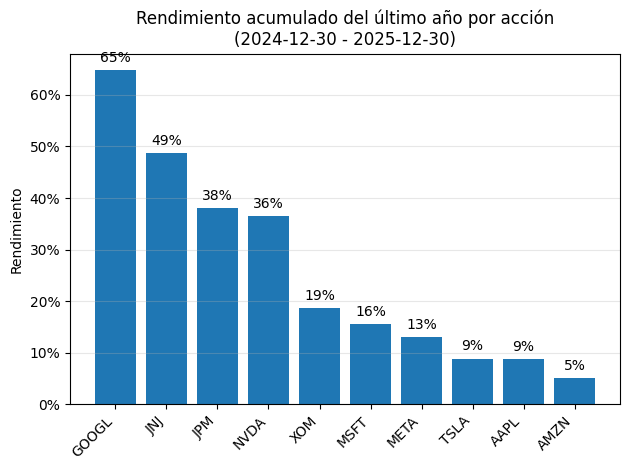

In [35]:
# rend acumulado del último año para cada acción
 
price_cols = [col for col in df.columns if col.startswith("ADJ_CLOSE")]
 
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.sort_values("DATE")
 
end = dfx["DATE"].max()
start = end - pd.DateOffset(years=1)
 
sub = dfx.loc[(dfx["DATE"] >= start) & (dfx["DATE"] <= end)]
 
rets = {}
for col in price_cols:
    s = sub[col].dropna()
    ticker = col.replace("ADJ_CLOSE_","")
    rets[ticker] = s.iloc[-1]/s.iloc[0] - 1
 
res = pd.Series(rets).sort_values(ascending = False)
tickers = res.index.to_list()
values = res.values
 
fig, ax = plt.subplots()
x = np.arange(len(tickers))
bars = ax.bar(x, values)
 
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation = 45, ha = "right")
ax.set_title(f"Rendimiento acumulado del último año por acción\n({start.date()} - {end.date()})")
ax.set_ylabel("Rendimiento")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, axis = "y", alpha = 0.3)
 
for xi, v in zip(x, values):
    ax.text(xi, v + (0.01 if v >= 0 else -0.01), f"{v:.0%}",
            ha = "center", va = "bottom" if v >= 0 else "top")
 
fig.tight_layout()
plt.show()

In [36]:

dfx

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM,DATE
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,2021-01-04
1,2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,2021-01-05
2,2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,2021-01-06
3,2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,2021-01-07
4,2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,2021-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600,2025-12-23
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400,2025-12-24
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100,2025-12-26


In [37]:
## Tarea: Grafico de barras con el rendimiento acumulado del portafolio para el ultimo ano, acumulado por mes - para todo el portagolio

df_grafico_barras = dfx.copy()

price_cols = [col for col in df_grafico_barras.columns if col.startswith("ADJ_CLOSE")]
df_grafico_barras["DATE"] = pd.to_datetime(df_grafico_barras["Date"], errors = "coerce")
df_grafico_barras = df_grafico_barras.sort_values("DATE")

#df_grafico_barras = df_grafico_barras.dropna()
#df_grafico_barras = df_grafico_barras.pct_change()

df_grafico_barras

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM,DATE
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856705,159.331497,85.599030,135.059647,110.051926,266.845947,208.406540,13.076016,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,2021-01-04
1,2021-01-05,127.412712,160.925507,86.289322,136.647568,110.650734,268.860107,208.607574,13.366435,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,2021-01-05
2,2021-01-06,123.123840,156.919006,85.437851,137.933456,115.846443,261.259796,203.198547,12.578443,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,2021-01-06
3,2021-01-07,127.325211,158.108002,87.989761,138.399445,119.650719,266.647461,208.980942,13.305861,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,2021-01-07
4,2021-01-08,128.424225,159.134995,89.154640,138.114655,119.782852,265.486603,210.254257,13.238801,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,2021-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600,2025-12-23
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400,2025-12-24
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100,2025-12-26


### Barchars

In [38]:
df["Date"]


0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1249   2025-12-23
1250   2025-12-24
1251   2025-12-26
1252   2025-12-29
1253   2025-12-30
Name: Date, Length: 1254, dtype: datetime64[ns]

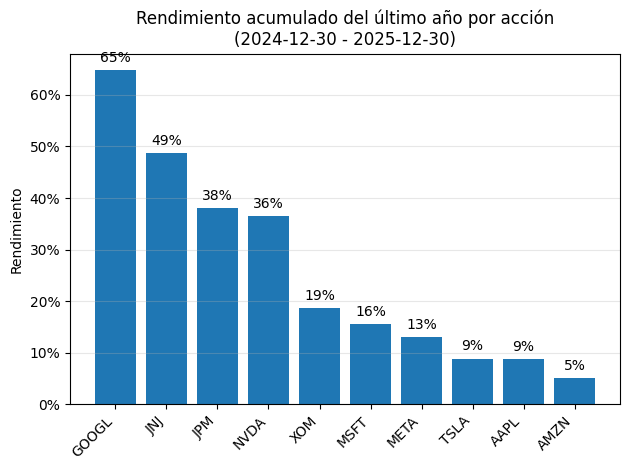

In [39]:
# rend acumulado del último año para cada acción

price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.sort_values("DATE")

end = dfx["DATE"].max()
start = end - pd.DateOffset(years=1)

sub = dfx.loc[(dfx["DATE"] >= start) & (dfx["DATE"] <= end)]

rets = {}
for col in price_cols:
    s = sub[col].dropna()
    ticker = col.replace("ADJ_CLOSE_","")
    rets[ticker] = s.iloc[-1]/s.iloc[0] - 1

res = pd.Series(rets).sort_values(ascending = False)
tickers = res.index.to_list()
values = res.values

fig, ax = plt.subplots()
x = np.arange(len(tickers))
bars = ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation = 45, ha = "right")
ax.set_title(f"Rendimiento acumulado del último año por acción\n({start.date()} - {end.date()})")
ax.set_ylabel("Rendimiento")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, axis = "y", alpha = 0.3)

for xi, v in zip(x, values):
    ax.text(xi, v + (0.01 if v >= 0 else -0.01), f"{v:.0%}",
            ha = "center", va = "bottom" if v >= 0 else "top")

fig.tight_layout()
plt.show()

### Grafico de Barras con el rendimiento acumulado del portafolio para el ultimo año, mostrado por mes

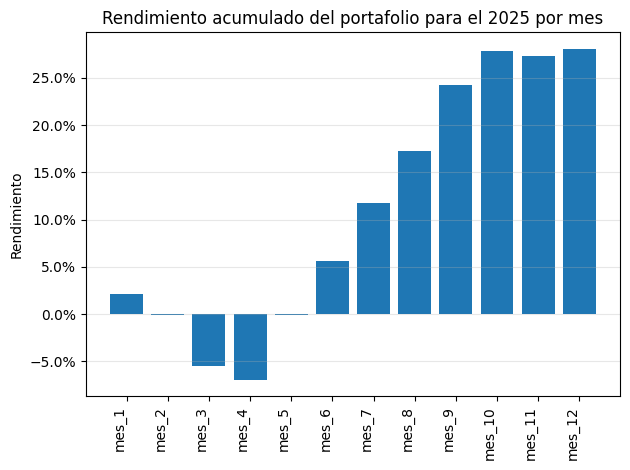

,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
228,282.835358,233.880005,314.462799,204.25415,307.532806,639.799927,485.631561,179.900253,430.140015,115.857765


,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
248,272.824707,232.529999,313.629242,205.815857,321.967712,665.38031,486.369904,187.529846,454.429993,120.188896


AAPL    -0.035394
AMZN    -0.005772
GOOGL   -0.002651
JNJ      0.007646
JPM      0.046938
META     0.039982
MSFT     0.001520
NVDA     0.042410
TSLA     0.056470
XOM      0.037383
Name: month 12, dtype: float64

np.float64(0.008044033772314184)

{'mes_1': np.float64(0.021243381203493564),
 'mes_2': np.float64(-0.0008845939161422102),
 'mes_3': np.float64(-0.055057502922251186),
 'mes_4': np.float64(-0.06973580961868515),
 'mes_5': np.float64(-0.0011660422331214726),
 'mes_6': np.float64(0.05584861144321736),
 'mes_7': np.float64(0.11778026266780837),
 'mes_8': np.float64(0.1722648110142435),
 'mes_9': np.float64(0.24218081275365838),
 'mes_10': np.float64(0.2789783210336698),
 'mes_11': np.float64(0.27279279541686036),
 'mes_12': np.float64(0.2808368291891745)}

In [ ]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

prices = df.copy()
prices["DATE"] = pd.to_datetime(prices["Date"], errors="coerce")
prices = prices.sort_values("DATE")

start_2025 = pd.Timestamp("2025-01-01")
end_2025   = pd.Timestamp("2025-12-31")

mask_2025 = (prices["DATE"] >= start_2025) & (prices["DATE"] <= end_2025)
p25 = prices.loc[mask_2025].reset_index(drop=True)

p25["MONTH"] = p25["Date"].dt.month

price_cols = [column for column in p25.columns if "ADJ_CLOSE_" in str(column)]
p25 = p25.loc[:, ["Date", "MONTH"]+price_cols]

rendimientos_mes = {}

for i in range(1,13):
    p25_temp = p25.copy()
    p25_temp = p25.loc[p25["MONTH"] == i]
    start_adj = p25_temp.loc[p25_temp["Date"] == p25_temp["Date"].min(), price_cols]
    end_adj = p25_temp.loc[p25_temp["Date"] == p25_temp["Date"].max(), price_cols]
    
    #tk_ren_mes = pd.Series(end_adj.values/start_adj.values - 1, index = start_adj.columns)
    tk_ren_mes = end_adj.values/start_adj.values - 1
    tk_ren_mes = pd.Series(tk_ren_mes[0], index = [column.replace("ADJ_CLOSE_","") for column in start_adj.columns], name=f"month {i}")
    ren_portafolio = np.sum([tk_ren_mes[tk]*weights[tk] for tk in weights.keys()])
    rendimientos_mes["mes_" + str(i)] = ren_portafolio

rend_acumulado = 0
for key, value in rendimientos_mes.items():
    rend_acumulado = rend_acumulado+value
    rendimientos_mes[key] = rend_acumulado

fig, ax = plt.subplots()
x = np.arange(len(rendimientos_mes.keys()))
bars = ax.bar(x, rendimientos_mes.values())

ax.set_xticks(x)
ax.set_xticklabels(rendimientos_mes.keys(), rotation = 90, ha = "right")
ax.set_title(f"Rendimiento acumulado del portafolio para el 2025 por mes")
ax.set_ylabel("Rendimiento")
ax.set_xlabel("Rendimiento ")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, axis = "y", alpha = 0.3)

fig.tight_layout()
plt.show()

display(start_adj)
display(end_adj)
display(tk_ren_mes)
display(ren_portafolio)
display(rendimientos_mes)

### Grouped Barchar

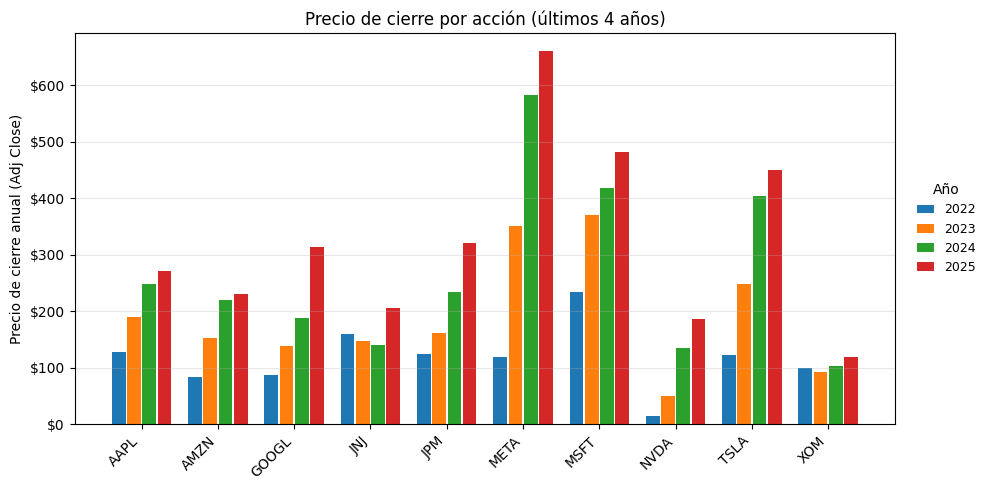

In [ ]:
# rend acumulado del último año para cada acción

price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["Date"], errors = "coerce")
dx = dx.sort_values("DATE")

# últimos 4 años disponibles en el DataFrame
years = sorted(dx["DATE"].dt.year.dropna().unique())[-4:]

tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

# matriz [ticker x año] con el ÚLTIMO precio disponible de cada año
mat = pd.DataFrame(index=tickers, columns=years, dtype=float)
for col in price_cols:
    tk = col.replace("ADJ_CLOSE_", "")
    tmp = dx[["DATE", col]].dropna()
    tmp["YEAR"] = tmp["DATE"].dt.year
    last_by_year = tmp.groupby("YEAR")[col].last()
    for y in years:
        mat.loc[tk, y] = last_by_year.get(y, np.nan)

# gráfico de barras agrupadas
x = np.arange(len(tickers))
n_years = len(years)
bar_w = 0.18
sep = 0.02

fig, ax = plt.subplots(figsize=(10, 5))
for i, y in enumerate(years):
    offset = (i - (n_years - 1) / 2) * (bar_w + sep)
    vals = mat[y].values
    ax.bar(x + offset, vals, width=bar_w, label=str(y))

ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_ylabel("Precio de cierre anual (Adj Close)")
ax.set_title(f"Precio de cierre por acción (últimos {n_years} años)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Año", loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, frameon=False,
    fontsize=9, title_fontsize=10, borderaxespad=0.0, handlelength=1.4 ,columnspacing=0.8)

# Opcional: formato moneda
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, pos: f"${v:,.0f}"))

fig.tight_layout()
plt.show()


In [ ]:
mat

,2022,2023,2024,2025
AAPL,127.879311,190.550461,249.059464,271.605835
AMZN,84.000000,151.940002,219.389999,230.820007
GOOGL,87.506760,138.544922,188.428864,312.779816
JNJ,160.397430,146.637955,139.582520,205.855652
JPM,123.985626,161.958359,233.686676,320.773071
META,119.402985,351.203949,583.170227,659.525330
MSFT,233.686661,369.671936,417.460602,482.518677
NVDA,14.598596,49.491749,134.246017,186.489914
TSLA,123.180000,248.479996,403.839996,449.720001
XOM,98.830086,92.641808,103.074768,119.543198


# Tarea: rendimiento maximo, minimo y promedio por acción

### Waffle Plot

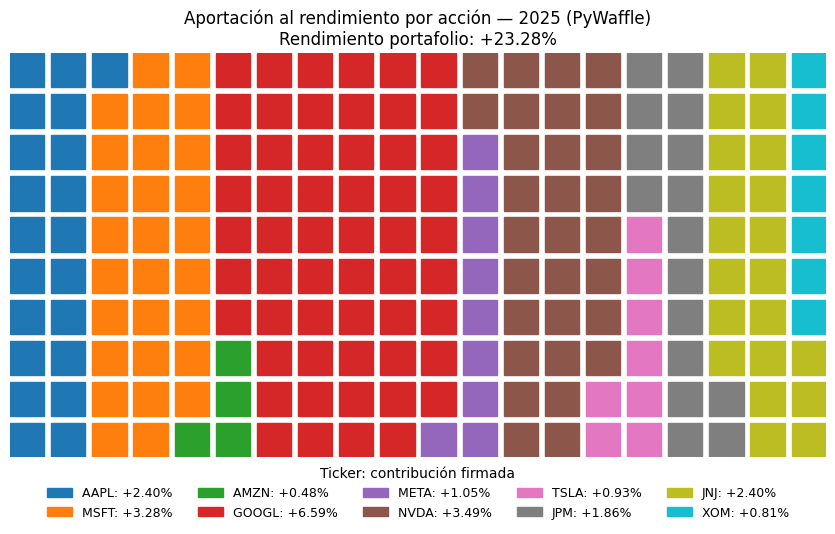

In [ ]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

TICKER_COLORS = {
    "AAPL": "#1f77b4",
    "MSFT": "#ff7f0e",
    "AMZN": "#2ca02c",
    "GOOGL":"#d62728",
    "META": "#9467bd",
    "NVDA": "#8c564b",
    "TSLA": "#e377c2",
    "JPM":  "#7f7f7f",
    "JNJ":  "#bcbd22",
    "XOM":  "#17becf",
}

TOTAL_TILES = 200  # tamaño del waffle (10x10)

prices = df.copy()
prices["DATE"] = pd.to_datetime(prices["Date"], errors="coerce")
prices = prices.sort_values("DATE")

# Ventana 2025
start_2025 = pd.Timestamp("2025-01-01")
end_2025   = pd.Timestamp("2025-12-31")
mask_2025 = (prices["DATE"] >= start_2025) & (prices["DATE"] <= end_2025)
p25 = prices.loc[mask_2025].reset_index(drop=True)

# Retornos por acción (YTD 2025) usando Adj Close
rets_2025, present = {}, []
for tk in weights.keys():
    col = f"ADJ_CLOSE_{tk}"
    s = p25[col].dropna()
    r = s.iloc[-1] / s.iloc[0] - 1.0
    rets_2025[tk] = float(r)
    present.append(tk)

# Pesos normalizados (si faltó alguno, re-normaliza con los presentes)
w = np.array([weights[tk] for tk in present], dtype=float)
w = w / w.sum()

# Contribución al rendimiento 2025: c_i = w_i * r_i
r = np.array([rets_2025[tk] for tk in present], dtype=float)
contrib = dict(zip(present, w * r))
port_ret_2025 = float(sum(contrib.values()))
magnitudes = np.abs(np.array([contrib[tk] for tk in present], dtype=float))
total_mag = magnitudes.sum()

proportions = magnitudes / total_mag * TOTAL_TILES
tiles_floor = np.floor(proportions).astype(int)
remainders = proportions - tiles_floor
missing = int(TOTAL_TILES - tiles_floor.sum())
order = np.argsort(-remainders)
tiles = tiles_floor.copy()
for i in range(missing):
    tiles[order[i]] += 1

mask_pos = tiles > 0
present_arr = np.array(present)[mask_pos]
tiles = tiles[mask_pos]
colors = [TICKER_COLORS.get(tk, "#999999") for tk in present_arr]
labels = [f"{tk}: {contrib[tk]:+,.2%}" for tk in present_arr]
values_dict = {lab: int(n) for lab, n in zip(labels, tiles)}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=values_dict,
    colors=colors,
    block_arranging_style="snake",
    starting_location="NW",
    figsize=(9, 6),
    legend={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.18),
        "ncol": 5,
        "frameon": False,
        "title": "Ticker: contribución firmada",
        "fontsize": 9
    },
)

plt.title(
    "Aportación al rendimiento por acción — 2025 (PyWaffle)\n"
    f"Rendimiento portafolio: {port_ret_2025:+.2%}"
)
plt.subplots_adjust(bottom=0.30)
plt.show()

### Stacked Barchar

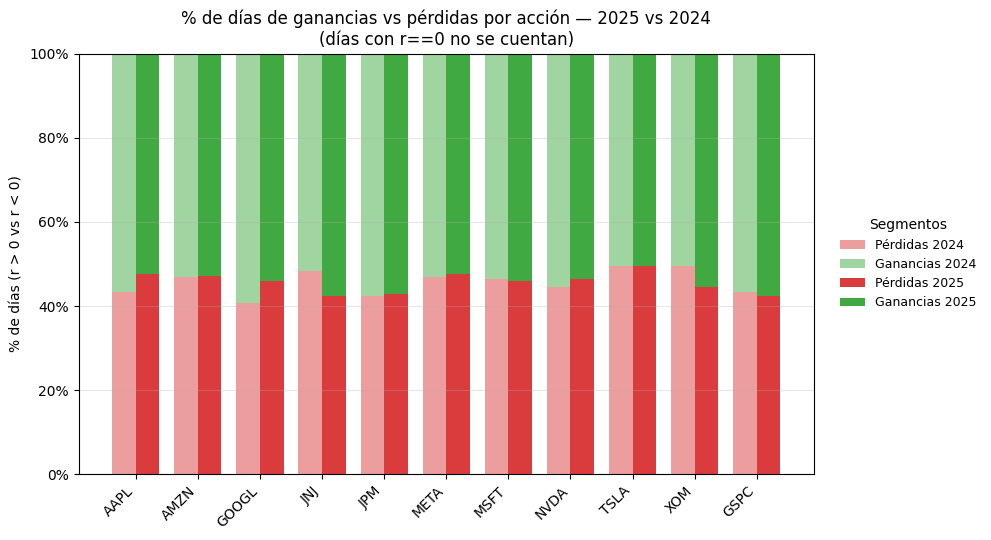

In [ ]:
price_cols = [c for c in df.columns if c.startswith("ADJ_CLOSE_")]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["Date"], errors="coerce")
dx = dx.sort_values("DATE")

end_date = dx["DATE"].max()
yr_curr  = int(end_date.year)
yr_prev  = yr_curr - 1

rets = dx[["DATE"] + price_cols].copy()
rets[price_cols] = rets[price_cols].pct_change()
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]
gain_curr, loss_curr, gain_prev, loss_prev = [], [], [], []

for col in price_cols:
    r = rets[["DATE", col]].dropna()
    rc = r[r["DATE"].dt.year == yr_curr][col]
    rp = r[r["DATE"].dt.year == yr_prev][col]

    gain_curr.append(int((rc > 0).sum()))
    loss_curr.append(int((rc < 0).sum()))
    gain_prev.append(int((rp > 0).sum()))
    loss_prev.append(int((rp < 0).sum()))

gain_curr = np.array(gain_curr, dtype=int)
loss_curr = np.array(loss_curr, dtype=int)
gain_prev = np.array(gain_prev, dtype=int)
loss_prev = np.array(loss_prev, dtype=int)

tot_curr = gain_curr + loss_curr
tot_prev = gain_prev + loss_prev

tot_curr = np.where(tot_curr == 0, 1, tot_curr)
tot_prev = np.where(tot_prev == 0, 1, tot_prev)
gain_curr_pct = gain_curr / tot_curr
loss_curr_pct = loss_curr / tot_curr
gain_prev_pct = gain_prev / tot_prev
loss_prev_pct = loss_prev / tot_prev


# https://htmlcolorcodes.com/
x = np.arange(len(tickers))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, loss_prev_pct, width=w, color="#d62728", alpha=0.45, label=f"Pérdidas {yr_prev}")
ax.bar(x - w/2, gain_prev_pct, width=w, bottom=loss_prev_pct, color="#2ca02c", alpha=0.45, label=f"Ganancias {yr_prev}")
ax.bar(x + w/2, loss_curr_pct, width=w, color="#d62728", alpha=0.9,  label=f"Pérdidas {yr_curr}")
ax.bar(x + w/2, gain_curr_pct, width=w, bottom=loss_curr_pct, color="#2ca02c", alpha=0.9,  label=f"Ganancias {yr_curr}")
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_ylabel("% de días (r > 0 vs r < 0)")
ax.set_title(f"% de días de ganancias vs pérdidas por acción — {yr_curr} vs {yr_prev}\n"
             "(días con r==0 no se cuentan)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)

ax.legend(
    title="Segmentos",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.subplots_adjust(right=0.80)
fig.tight_layout()
plt.show()

### Bubblecharts

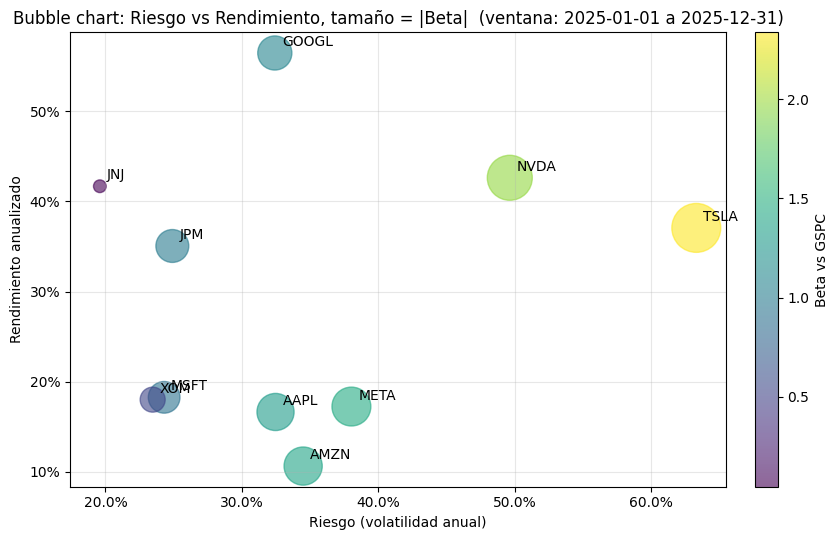

In [ ]:
price_cols = [c for c in df.columns if "ADJ_CLOSE_" in c and c != "ADJ_CLOSE_GSPC"]

dx = df.copy()
dx["DATE"] = pd.to_datetime(dx["Date"], errors="coerce")
dx = dx.sort_values("DATE")

end = dx["DATE"].max()
start = end - pd.DateOffset(years=1) + pd.DateOffset(days=1)

sub = dx.loc[(dx["DATE"] > start) & (dx["DATE"] <= end), ["DATE"] + price_cols + ["ADJ_CLOSE_GSPC"]]
sub = sub.dropna(how="all")

R = sub.set_index("DATE").pct_change().dropna(how="any")

mkt_col = "ADJ_CLOSE_GSPC"
tickers = [c.replace("ADJ_CLOSE_", "") for c in price_cols]

rows = []
for col in price_cols:
    pair = R[[col, mkt_col]].dropna()
    mu_ann = pair[col].mean() * 252.0
    sig_ann = pair[col].std(ddof=1) * np.sqrt(252.0)
    cov = pair.cov()
    beta = cov.loc[col, mkt_col] / cov.loc[mkt_col, mkt_col]  # beta vs mercado
    rows.append({"TICKER": col.replace("ADJ_CLOSE_", ""), "MU": mu_ann, "SIGMA": sig_ann, "BETA": beta})

metrics = pd.DataFrame(rows)

abs_beta = metrics["BETA"].abs().values
median_abs = np.median(abs_beta) if np.isfinite(abs_beta).any() else 1.0
scale = 600.0
sizes = scale * (abs_beta / (median_abs if median_abs > 0 else 1.0)) + 60.0  # tamaño mínimo

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(metrics["SIGMA"], metrics["MU"], s=sizes, c=metrics["BETA"], alpha=0.6)

for _, r in metrics.iterrows():
    ax.annotate(r["TICKER"], (r["SIGMA"], r["MU"]), xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Riesgo (volatilidad anual)")
ax.set_ylabel("Rendimiento anualizado")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Beta vs GSPC")

ax.set_title(f"Bubble chart: Riesgo vs Rendimiento, tamaño = |Beta|  (ventana: {start.date()} a {end.date()})")
fig.tight_layout()
plt.show()

In [ ]:
metrics

,TICKER,MU,SIGMA,BETA
0,AAPL,0.166449,0.324641,1.298115
1,AMZN,0.106437,0.344892,1.380444
2,GOOGL,0.564754,0.324116,1.078929
3,JNJ,0.416906,0.195866,0.047024
4,JPM,0.350619,0.249001,0.992835
5,META,0.172472,0.380266,1.436324
6,MSFT,0.182690,0.242988,0.911028
7,NVDA,0.426287,0.496366,1.961928
8,TSLA,0.370687,0.633076,2.337109
9,XOM,0.180130,0.234584,0.523618
